# 01 — Baseline CNN on CIFAR-10

**Project:** Progressive CNN Classifier Study
**Stage:** 1 of 6 — Plain CNN (no regularization)

### Goal
Build the simplest possible CNN — no Batch Normalization, no Dropout, no Data Augmentation, no LR scheduling — and train it on CIFAR-10.

This model's test accuracy becomes our **reference baseline**. Every later notebook (BatchNorm, Dropout, Augmentation, LR Scheduling, Transfer Learning) will be compared back to this number to show *how much each technique actually helps*.

### Dataset
**CIFAR-10**: 60,000 32x32 color images across 10 classes (50,000 train / 10,000 test).

### What this notebook covers
- Loading and normalizing image data
- Building a Sequential CNN with Conv2D + MaxPooling layers
- Compiling with an optimizer, loss function, and metric
- Training and validating
- Visualizing accuracy/loss curves
- Saving the trained model for later comparison

## 1. Imports

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Load and Preprocess CIFAR-10

- Pixel values originally range 0–255. We scale them to **0–1** (normalization) because neural networks train faster and more stably on small, centered input ranges.
- Labels are already integers (0–9), so we use `sparse_categorical_crossentropy` later instead of one-hot encoding.

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1871s 11us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


### Quick look at the data

Always sanity-check images and labels before training — catches loading/label-mapping bugs early.

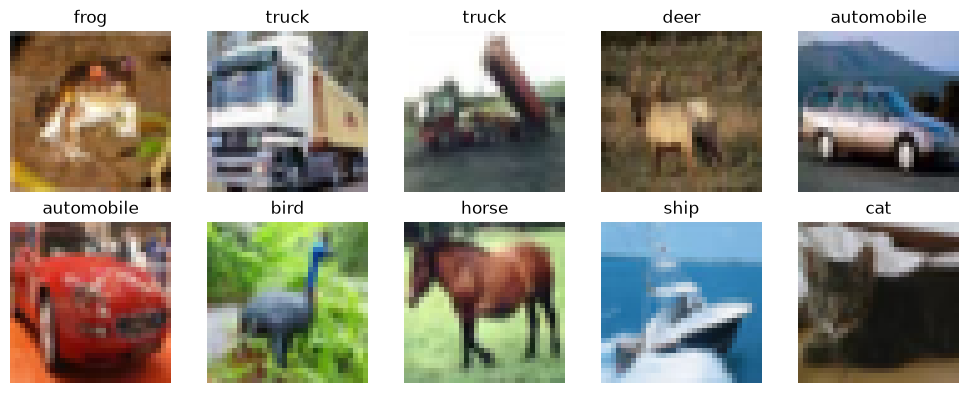

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Build the Baseline CNN

**Architecture logic:**
- `Conv2D` layers learn spatial feature detectors (edges → textures → shapes as depth increases).
- `MaxPooling2D` downsamples feature maps, reducing computation and adding a small amount of translation invariance.
- `Flatten` converts the final 2D feature maps into a 1D vector for the dense classifier head.
- `Dense(10, softmax)` outputs a probability distribution over the 10 CIFAR-10 classes.

**Deliberately excluded here** (added in later notebooks): BatchNorm, Dropout, Data Augmentation, LR scheduling.

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

/Users/adityagupta/Desktop/Machine learning/GDenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compile the Model

- **Optimizer — Adam:** adaptive learning rate, good default for most vision tasks.
- **Loss — sparse_categorical_crossentropy:** used because labels are integers, not one-hot vectors.
- **Metric — accuracy:** simple, interpretable classification metric for this balanced 10-class dataset.

In [5]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 5. Train the Model

We track both training and validation (test set) performance every epoch. Watch the gap between train and validation accuracy — a widening gap is the classic sign of **overfitting**, which this baseline (with zero regularization) is expected to show clearly. That's the whole point: later notebooks fix this.

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4093 - loss: 1.6184 - val_accuracy: 0.5237 - val_loss: 1.3110
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5603 - loss: 1.2355 - val_accuracy: 0.5949 - val_loss: 1.1519
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6179 - loss: 1.0807 - val_accuracy: 0.6282 - val_loss: 1.0606
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6586 - loss: 0.9790 - val_accuracy: 0.6589 - val_loss: 0.9773
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6856 - loss: 0.8991 - val_accuracy: 0.6731 - val_loss: 0.9342
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7073 - loss: 0.8407 - val_accuracy: 0.6740 - val_loss: 0.9352
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7259 - loss: 0.7866 - val_accuracy: 0.7021 - val_loss: 0.8689
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7402 - loss: 0.7460 - val_accuracy: 0.

## 6. Save the Model

Saved so it can be reloaded later for direct comparison against BatchNorm/Dropout/Augmentation/Transfer Learning versions without retraining.

In [7]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

model.save("models/baseline_cnn.h5")
print("Model saved to models/baseline_cnn.h5")

Model saved to models/baseline_cnn.h5


## 7. Visualize Training Curves

- **Accuracy plot:** if train accuracy keeps rising while validation accuracy plateaus/drops, that's overfitting.
- **Loss plot:** if validation loss starts increasing while training loss keeps falling, that's the clearest overfitting signal.

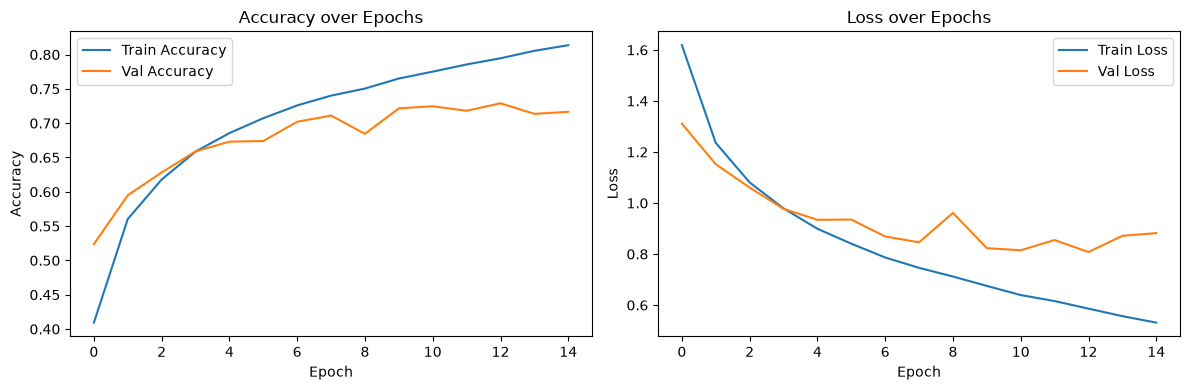

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/baseline_cnn_curves.png")
plt.show()

## 8. Final Evaluation

This test accuracy/loss is our **baseline reference score**. Write it down — every subsequent notebook (02–06) should report its own score against this one in your final report.

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7166 - loss: 0.8821
Final Test Accuracy: 0.7166
Final Test Loss: 0.8821


## Summary & Next Steps

| Notebook | Technique Added | Test Accuracy |
|---|---|---|
| 01 | None (baseline) | 0.7166 |
| 02 | + Batch Normalization | 0.6807 |
| 03 | + Dropout | 0.7250 |
| 04 | + Data Augmentation | 0.6359 / 0.6680 |
| 05 | + LR Scheduling | 0.7407 |
| 06 | Transfer Learning (MobileNetV2) | 0.8928 |

**Next:** proceed to `02_batchnorm.ipynb`, where we add Batch Normalization after each Conv2D layer and compare training stability and final accuracy against this baseline.